# Incendios investigados por la UAD y obras de prevención — análisis

Lee **exactamente lo que pinta el visor**: las capas de `frontend/public/data`
(14.705 incendios investigados, 1.863 fajas OECV, 1.114 verificadas en terreno y
327 puntos stand-by) más `manifest.json`, que es el contrato con los vocabularios.

El lector vive en [`analisis/leer_capas.py`](leer_capas.py) y es la contraparte en
Python de `frontend/src/App.jsx` + `hooks/useDatos.js`: mismo contrato, mismos
vocabularios, mismos centinelas. Este notebook **no reimplementa la lectura** — si
el ETL cambia el vocabulario, aquí cambia solo.

> ### Este visor no muestra incendios activos
>
> Cada punto es un incendio que **ya ocurrió** y que la UAD investigó después para
> determinar su causa. **No son todos los incendios del país**: son los
> investigados, 14.705 de las 14.985 filas de la base (280 se descartaron por no
> tener coordenada o caer fuera de Chile). Ninguna tasa nacional de ocurrencia
> sale de aquí.
>
> **No es una serie temporal comparable.** El alza del número entre temporadas
> refleja también la ampliación de la cobertura de investigación de la UAD; no
> debe leerse como aumento de la ocurrencia.
>
> **Cada incendio es un punto, no un perímetro.** `superficie_ha` es un atributo
> del punto: se puede sumar, pero no mapear como área ni intersecar con nada.

Las citas anteriores están tomadas del propio visor (`config.js:373`,
`CartelContexto.jsx:46-50`, `PanelIndicadores.jsx:156-159` y `:593-596`) y la
celda §3 comprueba que siguen ahí.

**¿Por qué aquí no hay un `.bin` como en el catastro?** Porque el reparto ya está
resuelto en dos niveles: la geometría pesada (19.242 líneas viales, 5,7 M de
vértices) **sí es binaria** —`rutas.pmtiles` y `redvial.pmtiles`, con peticiones
HTTP Range por viewport— y las capas ligeras se quedan en GeoJSON porque hay que
filtrarlas por atributo y tenerlas enteras en memoria igual. La idea que motiva un
`.bin` —no repetir cadenas— **sí está aplicada** dentro del JSON: `ETL/gj_io.py`
sustituye los categóricos por índices enteros contra tablas del manifest. Es
*dictionary encoding*; lo que cambia es el contenedor.

## 1 · Preparar el entorno

In [1]:
# Localiza la raiz del repo subiendo desde el cwd hasta encontrar las dos anclas.
# Asi el notebook funciona lo mismo abierto desde analisis/, desde la raiz o desde
# JupyterLab con otro directorio de trabajo.
import os, sys
from pathlib import Path

def raiz_repo(desde=None):
    p = Path(desde or os.getcwd()).resolve()
    for cand in (p, *p.parents):
        if (cand / "ETL" / "run.py").exists() and (cand / "frontend" / "src" / "config.js").exists():
            return cand
    raise FileNotFoundError("no encuentro la raiz del repo subiendo desde " + str(p))

RAIZ = raiz_repo()
sys.path.insert(0, str(RAIZ / "analisis"))

# `python` a secas en este equipo es el stub del Microsoft Store y falla con
# exit 49. Si el kernel es ese, mejor enterarse aqui que tres celdas mas abajo.
assert "WindowsApps" not in sys.executable, (
    "kernel equivocado: " + sys.executable + " es el stub del Store")
print("raiz del repo:", RAIZ)
print("interprete   :", sys.executable)
print("python       :", sys.version.split()[0])

raiz del repo: D:\GitHub\coipo_prevencion_incendio
interprete   : C:\ProgramData\anaconda3\python.exe
python       : 3.12.3


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import leer_capas as lc
from leer_capas import cargar, cargar_kpis, cargar_lineas, cargar_puntos, es, leer_manifest

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

for m in (np, pd, plt.matplotlib):
    print(f"{m.__name__:12} {m.__version__}")

numpy        1.26.4
pandas       2.2.2
matplotlib   3.9.2


## 2 · Cargar

`leer_manifest()` valida el contrato **antes de tocar un solo byte** de las capas,
y `cargar()` comprueba en cada carga que el archivo pesa los bytes que declara el
manifest, que trae las filas que declara, que el bbox coincide y que
`tabla[código]` reproduce la etiqueta fila a fila.

No hay ningún campo de versión en el manifest —ni constante de esquema en el ETL—
así que la generación se afirma con el **conjunto de campos codificados**. Es lo
que hace falta: el snapshot que había en este repo era del 2026-08-07 y declaraba
7 campos donde el ETL ya emitía 12, y eso no daba un error sino un DataFrame
plausible al que le faltaban los códigos oficiales de causa.

In [3]:
man = leer_manifest()
df = cargar()          # verificar=False para saltarse los chequeos mientras iteras

print(f"{es(len(df))} filas x {len(df.columns)} columnas")
print(f"{es(df.memory_usage(deep=True).sum() / 1e6, 1)} MB en memoria")
print(f"{es(df.superficie_ha.sum(), 2)} ha  ({es(int(df.superficie_ha.isna().sum()))} filas sin dato)")
print(f"esquema {lc.ESQUEMA} · huella {man['_huella'][:12]} · generado {man['generado']}")

14.705 filas x 42 columnas
5,7 MB en memoria
666.197,20 ha  (81 filas sin dato)
esquema incendios/2026-08-25 · huella 81394f9b5fb0 · generado 2026-08-27T10:25:59+0000


In [4]:
# Lo que declara el contrato, capa por capa.
pd.DataFrame([
    {"capa": c, "archivo": m["archivo"], "formato": m.get("formato"),
     "geometria": m.get("geometria"), "features": m.get("features"),
     "MB": round(m.get("bytes", 0) / 1e6, 2),
     "km": m.get("longitud_km"), "carga": m.get("carga")}
    for c, m in man["capas"].items()
]).set_index("capa")

,archivo,formato,geometria,features,MB,km,carga
capa,,,,,,,
incendios,incendios.geojson,geojson,Point,14705,7.97,NaN,inmediata
oecv,oecv.geojson,geojson,LineString,1863,0.93,"4,789.80",inmediata
oecv_verificado,oecv_verificado.geojson,geojson,LineString,1114,1.90,"1,471.80",inmediata
puntos_standby,puntos_standby.geojson,geojson,Point,327,0.05,NaN,inmediata
redvial,redvial.pmtiles,pmtiles,None,13964,18.80,NaN,demanda
rutas,rutas.pmtiles,pmtiles,None,5278,7.05,NaN,demanda


## 3 · Anatomía de las columnas

Cada dimensión sale **dos veces**: `<campo>` con la etiqueta legible y
`<campo>_cod` con el código. Pero **aquí `_cod` NO es un código oficial** —y esta
es la diferencia con el catastro—: es la *posición* en la tabla del manifest, que
`gj_io.codificar` ordena **por frecuencia descendente**, así que cambia entre
corridas del ETL. Sirve para volver al archivo; no se cita ni se publica sin
adjuntar su tabla.

Los únicos identificadores oficiales y citables de este dataset son
**`causa_codigo`** y **`causa_general_codigo`**, del catálogo de causas 2023.

In [5]:
resumen = pd.DataFrame([
    {"columna": c,
     "dtype": str(df[c].dtype),
     "categorias": df[c].nunique() if str(df[c].dtype) == "category" else "",
     "sin dato": int(df[c].isna().sum()),
     "% sin dato": f"{100 * df[c].isna().mean():.2f}".replace(".", ",")}
    for c in df.columns
])
resumen

,columna,dtype,categorias,sin dato,% sin dato
0,lon,float64,,0,"0,00"
1,lat,float64,,0,"0,00"
2,id,Int64,,6,"0,04"
3,n_incendio,string,,3,"0,02"
4,nombre,string,,0,"0,00"
5,region,category,16,0,"0,00"
6,region_cod,Int16,,0,"0,00"
7,provincia,category,51,74,"0,50"
8,provincia_cod,Int16,,74,"0,50"
9,comuna,category,350,67,"0,46"


### Lo que significa cada bloque de columnas

La columna **Vocabulario** distingue lo que se puede citar como oficial de lo que
sólo describe estos datos. `gj_io.dominios()` construye las tablas del manifest
**contando lo que aparece**: un valor que no ocurrió no existe en el vocabulario,
y el orden es por frecuencia. Eso es *inferido de los datos*, no una nomenclatura.

| Columnas | Qué es | Vocabulario |
|---|---|---|
| `lon` `lat` | Punto en EPSG:4326, redondeado a 5 decimales (~1,1 m). Es precisión de **almacenamiento**, no exactitud: el huso UTM de origen no venía declarado y se dedujo por región. **No sirve para trabajo predial ni legal** | — |
| `utm_x` `utm_y` `utm_epsg` | Las coordenadas tal como venían en el Excel. **El huso cambia por fila**: 8.645 en 18S y 6.060 en 19S | datos |
| `superficie_ha` `superficie_cero` | Superficie del incendio, promovida a `float64` al cargar. 71 filas valen exactamente 0,0 y no se sabe si es «muy pequeño» o «no registrado»: se marca, no se interpreta | — |
| `region` `provincia` `comuna` (+`_cod`) | Territorio. **Sin códigos INE/DPA**: sólo nombres. `provincia` y `comuna` traían `'Sin registro'` como etiqueta, traducido a `NA` | datos |
| `comuna_norm` `comuna_canon` | Clave de agrupación (310 comunas reales) y etiqueta para rotular. Ver §4.3 | derivado |
| `temporada` (+`_cod`) | Las 9 temporadas investigadas, de 2017-2018 a 2025-2026 | datos |
| `causa_grupo` `causa_general` `causa_especifica` (+`_cod`) | El árbol de causas: 5 grupos, 14 causas generales, 92 específicas. Es la causa **principal**, no una composición | guía oficial (catálogo 2023) |
| `causa_general_codigo` `causa_codigo` | **Los códigos oficiales.** `causa_codigo` es 1:1 con `causa_especifica`; `causa_general_codigo` **no** lo es con `causa_general` (ver §4.3) | guía oficial |
| `investigado_por` | Unidad UAD que investigó (82 valores tipo `UAD.9B`). No son personas | datos |
| `jefe_brigada` | **El encabezado del Excel miente.** No trae personas: trae códigos de causa en dos formatos, y coincide con `Causa investigada 2023` en el 0,2 % de las filas. Se emite con el nombre de origen para poder cotejarlo | datos |
| `mes_investigacion` | Mes, unificado desde 30 formas de escribir 12 meses. Conserva rangos legítimos como `Abril-Mayo` | datos |
| `inicio_r20` `hora_r20` | Del **reporte R20**, no del inicio del fuego | datos |
| `inv_inicio` `inv_fin` `inv_incoherente` | Fechas de la **investigación**, no del incendio. 24 filas terminan antes de empezar | datos |
| `informe` | Identificador del informe. `'Sin informe'` **se conserva**: dice que la investigación no produjo informe, que es un dato | datos |

In [6]:
# Las advertencias que este notebook cita estan ANCLADAS a su archivo fuente: si
# el visor reescribe el texto, aqui sale `sincronizada=False` en vez de propagar
# en silencio una frase que la app ya no dice.
adv = lc.verificar_advertencias(RAIZ)
print("advertencias del visor sincronizadas:", bool(adv.sincronizada.all()))
adv[["archivo", "ancla", "sincronizada"]]

advertencias del visor sincronizadas: True


,archivo,ancla,sincronizada
0,frontend/src/config.js,Este visor no muestra incendios activos,True
1,frontend/src/components/CartelContexto.jsx,no son todos los incendios,True
2,frontend/src/components/PanelIndicadores.jsx,no la totalidad de los incendios,True
3,frontend/src/components/PanelIndicadores.jsx,no debe leerse como aumento,True
4,frontend/src/components/PanelIndicadores.jsx,La comparacion no implica causalidad,True
5,frontend/src/components/PanelIndicadores.jsx,no necesariamente de brigadas,True
6,frontend/src/components/PanelIndicadores.jsx,no una lista de recomendaciones,True


In [7]:
df.head(5)[["id", "lon", "lat", "superficie_ha", "causa_grupo", "causa_general",
            "causa_general_codigo", "comuna", "region", "temporada"]]

,id,lon,lat,superficie_ha,causa_grupo,causa_general,causa_general_codigo,comuna,region,temporada
0,1,-72.90,-38.52,1.20,Negligentes,Faenas forestales,4.1,Cholchol,La Araucanía,2017-2018
1,2,-72.70,-38.34,0.12,Negligentes,Faenas forestales,4.1,Traiguén,La Araucanía,2017-2018
2,3,-72.81,-38.37,0.30,Negligentes,Faenas forestales,4.1,Galvarino,La Araucanía,2017-2018
3,4,-72.69,-38.56,0.40,Negligentes,Faenas forestales,4.1,Temuco,La Araucanía,2017-2018
4,5,-72.60,-38.71,0.40,Negligentes,Faenas forestales,4.1,Temuco,La Araucanía,2017-2018


## 4 · Las cuatro trampas

Ninguna es teórica: las cuatro están medidas sobre este dataset, y las celdas de
abajo las vuelven a medir cada vez que se ejecuta el notebook.

### 4.1 · Acumulación en `float32`

El formato publicado es **JSON de texto**: no hay ni un `f32` en el archivo. Así
que aquí la trampa no la pone el dato sino el lector que degrade al cargar. El
lector fuerza `float64` y comprueba que ninguna columna quedó en `float32`.

In [8]:
import math
s = df.superficie_ha.dropna().to_numpy()

f64 = s.sum(dtype=np.float64)
f32 = float(s.astype(np.float32).sum(dtype=np.float32))

print(f"n = {es(len(s))} superficies")
print(f"  suma en f64          {es(f64, 2):>16} ha   <- lo que publica el visor")
print(f"  suma acumulando f32  {es(f32, 2):>16} ha   <- {es(f32 - f64, 4)} ha de diferencia")
print(f"  error relativo       {abs(f32 - f64) / f64 * 100:.7f} %   (un ULP de f32 a esta magnitud)")
print()
print(f"  math.fsum  {es(math.fsum(s), 2)}   np.sum  {es(f64, 2)}   sum()  {es(sum(s), 2)}   <- identicos en f64")
print()
print("  columnas float32 en el DataFrame:",
      [c for c in df.columns if str(df[c].dtype) == "float32"] or "ninguna")

n = 14.624 superficies
  suma en f64                666.197,20 ha   <- lo que publica el visor
  suma acumulando f32        666.197,25 ha   <- 0,0500 ha de diferencia
  error relativo       0.0000075 %   (un ULP de f32 a esta magnitud)

  math.fsum  666.197,20   np.sum  666.197,20   sum()  666.197,20   <- identicos en f64

  columnas float32 en el DataFrame: ninguna


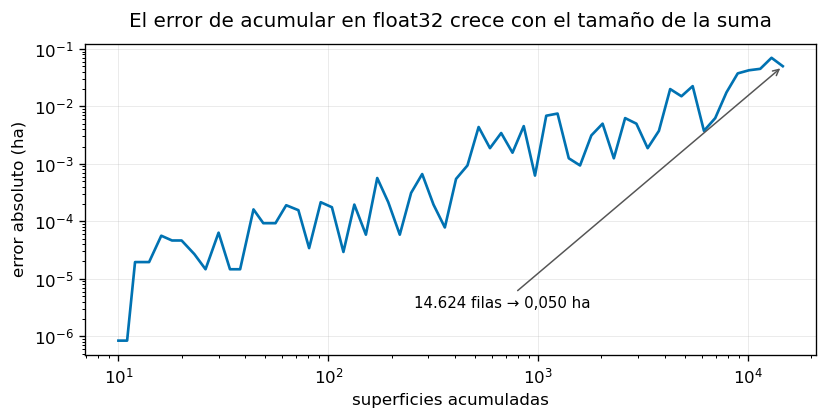

In [9]:
# El error de f32 no es constante: crece con el numero de sumandos. Por eso una
# cifra nacional lo acusa y un total comunal no.
ns = np.unique(np.geomspace(10, len(s), 60).astype(int))
err = [abs(float(s[:n].astype(np.float32).sum(dtype=np.float32)) - s[:n].sum(dtype=np.float64))
       for n in ns]

fig, ax = plt.subplots(figsize=(7, 3.6), dpi=120)
ax.plot(ns, err, color="#0072B2", lw=1.6)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("superficies acumuladas"); ax.set_ylabel("error absoluto (ha)")
ax.set_title("El error de acumular en float32 crece con el tamaño de la suma", pad=10)
ax.grid(alpha=0.25, lw=0.6)
ax.annotate(f"{es(len(s))} filas → {es(err[-1], 3)} ha",
            xy=(ns[-1], err[-1]), xytext=(0.45, 0.15), textcoords="axes fraction",
            arrowprops=dict(arrowstyle="->", lw=0.9, color="#555"), fontsize=9)
plt.tight_layout(); plt.show()

### 4.2 · Los centinelas no son datos

El ETL ya tradujo los suyos a **claves ausentes**: no hay `-1` ni `null`, la clave
simplemente no está en `properties`. Pero varios **sobreviven como etiqueta real**
dentro de las tablas del manifest, y sin traducirlos se convierten en una
categoría más.

Se comparan por **igualdad exacta** sobre la clave normalizada, nunca por
subcadena: varias causas específicas legítimas contienen «sin » (*«…que se propaga
libre y sin control»*) y una comparación laxa las tiraría a `NA`.

Y hay **dos excepciones que no se tocan**, por eso los centinelas se aplican por
capa y no globalmente:

- `'Sin informe'` **no** es centinela: dice que la investigación no produjo
  informe, que es un dato.
- `'Sin determinar'` en `oecv.tipo` **sí** es una categoría oficial de titularidad
  (Memo N° 3045/2025). En `jefe_brigada` es un centinela; en `oecv.tipo` no.

In [10]:
filas = []
for campo, d in df.attrs["centinelas_aplicados"].items():
    for etiqueta, n in d.items():
        filas.append({"campo": campo, "etiqueta": etiqueta, "filas": n,
                      "% del campo": 100 * n / len(df)})
cent = pd.DataFrame(filas).sort_values("filas", ascending=False)
print(f"{es(int(cent.filas.sum()))} filas traducidas a NA en {cent.campo.nunique()} campos\n")
cent

1.360 filas traducidas a NA en 3 campos



,campo,etiqueta,filas,% del campo
2,jefe_brigada,Sin información,664,4.52
3,jefe_brigada,Sin estimar,231,1.57
4,jefe_brigada,Sin causa,219,1.49
0,provincia,Sin registro,74,0.50
1,comuna,Sin registro,67,0.46
5,jefe_brigada,Sin determinar,42,0.29
6,jefe_brigada,Sin Información,36,0.24
7,jefe_brigada,Sin Estimar,20,0.14
8,jefe_brigada,--,5,0.03
9,jefe_brigada,Período sin brigada,1,0.01


In [11]:
# El caso extremo: sin traducir, 'Sin informacion' seria la 5a categoria mas
# frecuente de jefe_brigada.
crudo = cargar(man=man, centinelas=False)
print("jefe_brigada SIN traducir los centinelas — 6 valores mas frecuentes:")
print(crudo.jefe_brigada.value_counts().head(6).to_string())
print()
print(f"  NA con centinelas activos: {es(int(df.jefe_brigada.isna().sum()))} "
      f"({100 * df.jefe_brigada.isna().mean():.2f} %)")
print(f"  NA sin traducirlos:        {es(int(crudo.jefe_brigada.isna().sum()))} "
      f"({100 * crudo.jefe_brigada.isna().mean():.2f} %)")

jefe_brigada SIN traducir los centinelas — 6 valores mas frecuentes:
jefe_brigada
5.1                2376
2.1                1865
4.1.2              1555
4.8                 719
Sin información     664
1.7.1               591

  NA con centinelas activos: 2.864 (19.48 %)
  NA sin traducirlos:        1.645 (11.19 %)


In [12]:
# Y las fechas que el ETL dio por buenas y no pueden serlo. `norm_fecha` valida el
# FORMATO, no el calendario: un anno tecleado al reves pasa el strptime tan
# campante. No se corrigen --corregir una fecha es inventar un dato-- se reportan.
for campo, d in df.attrs["fechas_sospechosas"].items():
    for tipo, v in d.items():
        print(f"  {campo:20} {tipo:20} n={v['n']:<5} {v.get('valores', '')}")
print()
print(f"  71 filas con superficie_ha == 0,0 exacto: round(sup,2) en el ETL colapsa")
print(f"  todo lo menor a 0,005 ha, asi que 'muy pequenno' y 'no registrado' se")
print(f"  confunden. Marcadas en `superficie_cero`, no convertidas a NA.")

  inicio_r20           posteriores_al_etl   n=1     ['2028-01-18']
  inv_inicio           posteriores_al_etl   n=1     ['2026-12-10']
  inv_fin              fuera_de_rango       n=3     ['0203-01-25', '0203-03-07', '0203-03-14']
  inv_fin              posteriores_al_etl   n=2     ['2029-06-10']
  inv_inicio/inv_fin   incoherentes         n=24    

  71 filas con superficie_ha == 0,0 exacto: round(sup,2) en el ETL colapsa
  todo lo menor a 0,005 ha, asi que 'muy pequenno' y 'no registrado' se
  confunden. Marcadas en `superficie_cero`, no convertidas a NA.


### 4.3 · Las etiquetas se repiten entre códigos distintos

Aquí ocurre de **tres formas** y las tres importan.

**(a) En ambas direcciones dentro de `causa_general`.** Es la forma literal de la
trampa, y es la más grave porque afecta al campo que el visor usa como filtro.

In [13]:
pares = lc.pares_etiqueta_codigo(df, "causa_general", "causa_general_codigo")
por_etiqueta = pares.groupby("causa_general", observed=True).size()
por_codigo   = pares.groupby("causa_general_codigo", observed=True).size()

print(f"{df.causa_general.nunique()} etiquetas y {df.causa_general_codigo.nunique()} "
      f"codigos oficiales producen {len(pares)} pares distintos")
print(f"  etiquetas con MAS DE UN codigo oficial: {(por_etiqueta > 1).sum()}")
print(f"  codigos oficiales con MAS DE UNA etiqueta: {(por_codigo > 1).sum()}  "
      f"-> {list(por_codigo[por_codigo > 1].index)}")
print()
pares[pares.causa_general.isin(por_etiqueta[por_etiqueta > 1].index)]

14 etiquetas y 21 codigos oficiales producen 23 pares distintos
  etiquetas con MAS DE UN codigo oficial: 9
  codigos oficiales con MAS DE UNA etiqueta: 2  -> ['4.1', '1.1']



,causa_general,causa_general_codigo,n
1,Otras quemas,4.8,2485
2,Líneas eléctricas,4.9,1143
3,Faenas agrícolas y pecuarias,4.2,1074
4,Otras causas,4.1,1006
5,Faenas forestales,4.1,914
6,"Parcelaciones, edificaciones residenciales, in...",4.6,858
7,Actividades al aire libre,4.3,487
9,Faenas agrícolas y pecuarias,1.2,379
11,"Originados por desplazamiento de personas, veh...",4.7,269
13,"Parcelaciones, edificaciones residenciales, in...",1.6,188


In [14]:
# La direccion contraria, que es la que rompe cualquier agregacion por codigo:
# el codigo 4.1 son DOS causas generales distintas.
pares[pares.causa_general_codigo.isin(por_codigo[por_codigo > 1].index)].sort_values(
    ["causa_general_codigo", "n"], ascending=[True, False])

,causa_general,causa_general_codigo,n
4,Otras causas,4.1,1006
5,Faenas forestales,4.1,914
17,Faenas forestales,1.1,79
18,Otras causas,1.1,50


In [15]:
# En cambio causa_especifica x causa_codigo SI es 1:1 perfecta: ahi el codigo
# oficial identifica sin ambiguedad y es el que hay que usar.
p2 = lc.pares_etiqueta_codigo(df, "causa_especifica", "causa_codigo")
m2 = p2.groupby("causa_especifica", observed=True).size()
print(f"causa_especifica: {df.causa_especifica.nunique()} etiquetas, "
      f"{df.causa_codigo.nunique()} codigos, {len(p2)} pares, "
      f"{(m2 > 1).sum()} etiquetas con mas de un codigo")

causa_especifica: 92 etiquetas, 92 codigos, 92 pares, 0 etiquetas con mas de un codigo


**(b) Entre vocabularios distintos.** La misma cadena aparece en varios campos: sin
decir de qué campo, una etiqueta no identifica nada.

In [16]:
col = lc.colisiones_entre_campos(man)
print(f"{len(col)} etiquetas aparecen en mas de un vocabulario\n")
col[col.etiqueta.isin(["Valparaíso", "Aysén", "Biobío", "Sin registro", "Maule"])]

88 etiquetas aparecen en mas de un vocabulario



,etiqueta,campos,indices
59,Aysén,"[region, provincia, comuna]","[10, 43, 245]"
60,Biobío,"[region, provincia]","[1, 3]"
74,Maule,"[region, comuna]","[2, 28]"
83,Sin registro,"[provincia, comuna]","[33, 71]"
87,Valparaíso,"[region, provincia, comuna]","[5, 13, 7]"


**(c) La misma comuna bajo varios códigos.** Variantes de mayúsculas y espacios
parten comunas reales en hasta 6 códigos. Agrupar por código **sobre-fragmenta**, y
agrupar por la etiqueta cruda también, porque las etiquetas difieren.

> **Regla práctica:** agrupa por **`comuna_norm`**, rotula con **`comuna_canon`**, y
> cita `comuna` cuando reportes una fila concreta. No se destruye ninguna de las tres.

In [17]:
fr = lc.fragmentacion(man, "comuna")
print(f"{len(fr)} comunas repartidas en {int(fr.n_codigos.sum())} codigos distintos")
print(f"afecta a {es(int(fr.filas.sum()))} filas = {100 * fr.filas.sum() / len(df):.1f} % del total")
print(f"{fr.attrs['codigos']} codigos de comuna colapsan a {fr.attrs['claves']} comunas reales\n")
fr.sort_values("n_codigos", ascending=False).head(6)[["clave", "n_codigos", "filas", "variantes"]]

35 comunas repartidas en 76 codigos distintos
afecta a 2.450 filas = 16.7 % del total
351 codigos de comuna colapsan a 310 comunas reales



,clave,n_codigos,filas,variantes
6,san pedro de la paz,6,110,"[San Pedro de la Paz, San Pedro de La Paz, San..."
1,padre las casas,3,197,"[Padre las Casas, Padre Las Casas, Padre las c..."
16,talcahuano,3,55,"[Talcahuano, talcahuano, TALCAHUANO]"
0,lebu,2,216,"[Lebu, LEBU]"
26,ninhue,2,34,"[Ninhue, NINHUE]"
21,pinto,2,39,"[Pinto, PINTO]"


In [18]:
# Lo que cuesta en un ranking: las mismas comunas, contadas de las tres formas.
por_codigo   = df.groupby("comuna_cod", observed=True).size()
por_etiqueta = df.groupby("comuna", observed=True).size()
por_norm     = df.groupby("comuna_norm", observed=True).size()

canon = df.dropna(subset=["comuna_norm"]).groupby("comuna_norm", observed=True).comuna_canon.first()
top = por_norm.sort_values(ascending=False).head(10)

pd.DataFrame({
    "comuna": canon.reindex(top.index).values,
    "agrupando por comuna_norm": top.values,
    "agrupando por la etiqueta cruda": [
        int(por_etiqueta.get(canon.get(k), 0)) for k in top.index],
}, index=top.index).rename_axis("clave")

,comuna,agrupando por comuna_norm,agrupando por la etiqueta cruda
clave,,,
los angeles,Los Ángeles,348,348
galvarino,Galvarino,319,319
temuco,Temuco,299,299
tome,Tomé,290,290
collipulli,Collipulli,228,228
lebu,Lebu,216,191
chillan,Chillán,213,213
victoria,Victoria,212,212
valparaiso,Valparaíso,204,204


### 4.4 · `groupby` descarta los `NA` por defecto

Y aquí las trampas 2 y 4 son **la misma trampa vista dos veces**: en las columnas
territoriales los ausentes eran **cero** hasta que se tradujeron los centinelas. Al
convertir `'Sin registro'` en `NA`, `provincia` pasa a 74 `NA` y `comuna` a 67, y
sólo entonces un `groupby` por omisión empieza a perder filas en silencio.

In [19]:
print(f"{'columna':<18}{'pandas por omision':>18}{'dropna=False':>16}{'pierde':>10}")
print("-" * 60)
for campo in ("region", "provincia", "comuna", "mes_investigacion", "inv_inicio"):
    a = int(df.groupby(campo, observed=True).size().sum())
    b = int(df.groupby(campo, observed=True, dropna=False).size().sum())
    print(f"{campo:<18}{es(a):>18}{es(b):>16}{es(b - a):>10}")
print()
print("Y con los centinelas SIN traducir, las territoriales no pierden nada:")
for campo in ("provincia", "comuna"):
    a = int(crudo.groupby(campo, observed=True).size().sum())
    print(f"  {campo:<12} pandas por omision = {es(a)}  (de {es(len(crudo))})")

columna           pandas por omision    dropna=False    pierde
------------------------------------------------------------
region                        14.705          14.705         0
provincia                     14.631          14.705        74
comuna                        14.638          14.705        67
mes_investigacion             14.671          14.705        34
inv_inicio                     9.815          14.705     4.890

Y con los centinelas SIN traducir, las territoriales no pierden nada:
  provincia    pandas por omision = 14.705  (de 14.705)
  comuna       pandas por omision = 14.705  (de 14.705)


In [20]:
# `agrupar` conserva los NA y ADEMAS dice cuantas filas habria perdido la otra via.
import warnings
with warnings.catch_warnings(record=True) as avisos:
    warnings.simplefilter("always")
    t = lc.agrupar(df, "comuna_norm")
for a in avisos:
    print("AVISO:", a.message)
print()
print(f"total agrupado: {es(int(t.sum()))} de {es(len(df))} filas")

AVISO: 67 filas (0,46 %) caen en el grupo NA de comuna_norm; un groupby por omision las habria descartado en silencio

total agrupado: 14.705 de 14.705 filas


## 5 · Reconciliación contra las cifras publicadas

El lector no vale nada si no se puede demostrar que es fiel. Estas son **todas** las
cifras ya publicadas que hay en el repo: el propio `manifest.json` (bytes, features,
km, km por región), `kpis.json` (planificado, reportado, avance) y la constante
`KM_OFICIAL_NACIONAL` de `ETL/build_oecv.py`, que es la única cifra oficial
independiente del ETL. `reconciliar()` corre esto mismo en cada carga.

In [21]:
rec = lc.reconciliar(man=man)
malos = rec[rec.ok == False]
print(f"{len(rec) - len(malos)}/{len(rec)} chequeos cuadran"
      + ("" if malos.empty else f" — {len(malos)} NO cuadran"))
rec

37/37 chequeos cuadran


,chequeo,medido,publicado,ok,nota
0,incendios: bytes en disco,7970573,"7,970,573.00",True,el manifest lo declara y el visor nunca lo con...
1,oecv: bytes en disco,930046,"930,046.00",True,el manifest lo declara y el visor nunca lo con...
2,oecv_verificado: bytes en disco,1895780,"1,895,780.00",True,el manifest lo declara y el visor nunca lo con...
3,puntos_standby: bytes en disco,54824,"54,824.00",True,el manifest lo declara y el visor nunca lo con...
4,redvial: bytes en disco,18801957,"18,801,957.00",True,el manifest lo declara y el visor nunca lo con...
5,rutas: bytes en disco,7051850,"7,051,850.00",True,el manifest lo declara y el visor nunca lo con...
6,incendios: leidos - descartados,14705,"14,705.00",True,14.985 filas de origen menos 280 descartadas
7,oecv: features,1863,"1,863.00",True,
8,oecv: km,"4,789.78","4,789.80",True,
9,oecv: km Antofagasta,2.23,2.20,True,el manifest redondea a 1 decimal


### Un bug real en los datos publicados

`kpis.json` escribe la clave de O'Higgins con **acento agudo `U+00B4`** mientras las
capas usan el **apóstrofo `U+0027`**. Un *join* literal pierde O'Higgins, que es la
**2ª región del país** por kilómetros planificados (836,8). El frontend lo parchea en
`indicadores.js:18-22`; en Python **no existe equivalente** —ni `geo.canon_region` ni
`build_kpis.py` lo hacen— así que el lector replica el parche y lo declara.

In [22]:
k = cargar_kpis(man=man)
regiones_capa = set(man["capas"]["incendios"]["tablas"]["region"])

literal = sorted(set(k.region_bruta) & regiones_capa)
normal  = sorted(set(k.index) & regiones_capa)
print(f"join literal:        {len(literal)}/16 regiones casan")
print(f"con norm_region():   {len(normal)}/16")
print(f"la que se pierde:    {sorted(set(normal) - set(literal))}")
print()
bruta = k.loc["O'Higgins", "region_bruta"]
print(f"kpis.json escribe {bruta!r}  ->  codepoints {[hex(ord(c)) for c in bruta[:2]]}")
print(f"las capas escriben {chr(79) + chr(39) + 'Higgins'!r}  ->  codepoints ['0x4f', '0x27']")
print()
print("Y 'Arica y Parinacota' no trae la clave 'reportado' en el JSON:")
print(f"  k.loc['Arica y Parinacota','reportado'] = {k.loc['Arica y Parinacota','reportado']}  (NA, no KeyError)")

join literal:        15/16 regiones casan
con norm_region():   16/16
la que se pierde:    ["O'Higgins"]

kpis.json escribe 'O´Higgins'  ->  codepoints ['0x4f', '0xb4']
las capas escriben "O'Higgins"  ->  codepoints ['0x4f', '0x27']

Y 'Arica y Parinacota' no trae la clave 'reportado' en el JSON:
  k.loc['Arica y Parinacota','reportado'] = nan  (NA, no KeyError)


## 6 · Ejemplos de análisis

In [23]:
# Causa de los incendios investigados. La segunda cifra son hectareas y NO ordena
# igual que el recuento: es el aviso que el propio visor hace.
t = lc.agrupar(df, "causa_grupo", avisar=False)
ha = df.groupby("causa_grupo", observed=True).superficie_ha.sum()

pd.DataFrame({
    "incendios": t,
    "% de incendios": 100 * t / t.sum(),
    "hectareas": ha.reindex(t.index),
    "% de superficie": 100 * ha.reindex(t.index) / ha.sum(),
    "ha por incendio": ha.reindex(t.index) / t,
})

,incendios,% de incendios,hectareas,% de superficie,ha por incendio
causa_grupo,,,,,
Negligentes,8730,59.37,"367,820.94",55.21,42.13
Intencionales,4484,30.49,"243,168.25",36.50,54.23
Accidentales,972,6.61,"34,671.52",5.20,35.67
Indeterminadas,423,2.88,"12,665.10",1.90,29.94
Naturales,96,0.65,"7,871.39",1.18,81.99


In [24]:
# Causa general: cuarta por recuento, segunda por superficie. El orden cambia
# segun lo que se mida, y por eso el visor pone las dos cifras juntas.
n  = df.groupby("causa_general", observed=True).size()
ha = df.groupby("causa_general", observed=True).superficie_ha.sum()
comp = pd.DataFrame({"incendios": n, "hectareas": ha})
comp["rank_n"]  = comp.incendios.rank(ascending=False).astype(int)
comp["rank_ha"] = comp.hectareas.rank(ascending=False).astype(int)
comp["salto"]   = comp.rank_n - comp.rank_ha
comp.sort_values("incendios", ascending=False)

,incendios,hectareas,rank_n,rank_ha,salto
causa_general,,,,,
Incendios intencionales,4484,"243,168.25",1,1,0
Otras quemas,2490,"25,397.32",2,7,-5
Faenas agrícolas y pecuarias,1453,"40,938.17",3,4,-1
Líneas eléctricas,1248,"150,642.66",4,2,2
Otras causas,1056,"20,030.38",5,9,-4
"Parcelaciones, edificaciones residenciales, industriales u otras en zonas rurales o de interfaz",1046,"54,564.37",6,3,3
Faenas forestales,993,"18,765.95",7,10,-3
Actividades al aire libre,495,"24,370.61",8,8,0
Incendios de causa indeterminada,423,"12,665.10",9,11,-2


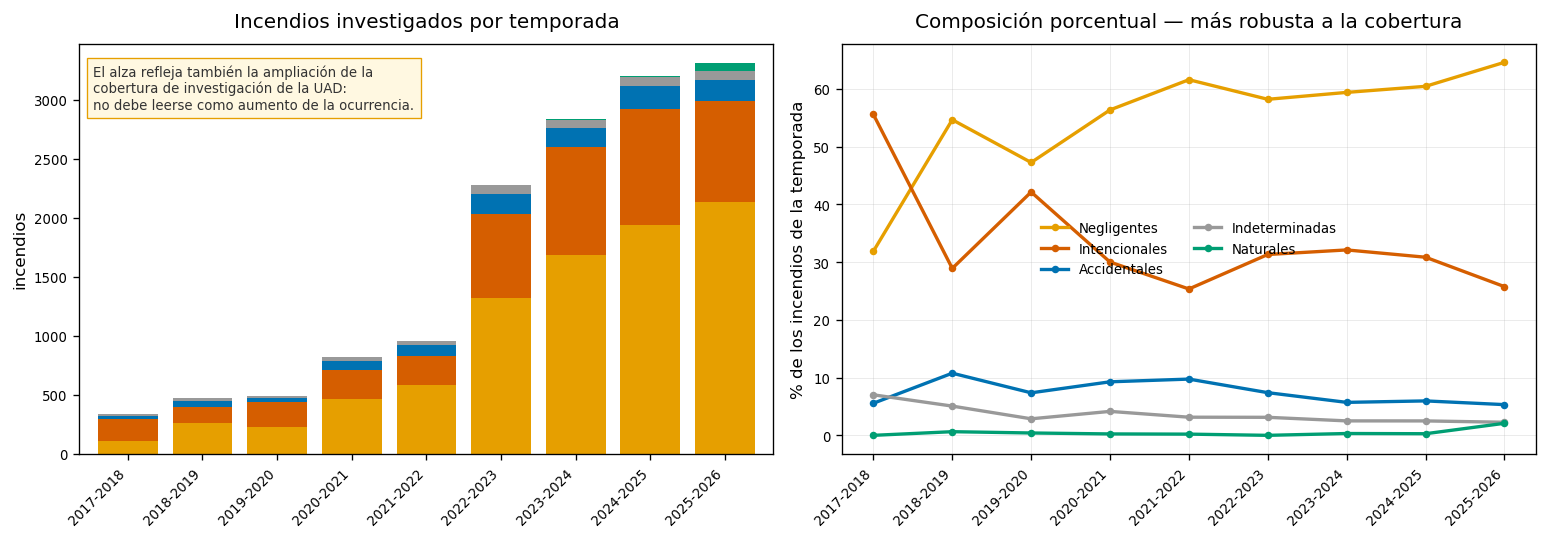

In [25]:
# Serie por temporada. OJO: el alza refleja tambien la ampliacion de la cobertura
# de investigacion de la UAD, no necesariamente mas incendios.
orden = sorted(df.temporada.dropna().unique())
serie = df.groupby(["temporada", "causa_grupo"], observed=True).size().unstack(fill_value=0)
serie = serie.reindex(orden)

PAL = lc.paleta_del_visor("causa", RAIZ, clases=list(serie.columns))
prop = serie.div(serie.sum(axis=1), axis=0) * 100

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.6), dpi=120)
serie.plot.bar(stacked=True, ax=a1, color=[PAL[c] for c in serie.columns], width=0.8, legend=False)
a1.set_title("Incendios investigados por temporada", pad=10)
a1.set_xlabel(""); a1.set_ylabel("incendios")
a1.text(0.02, 0.95, "El alza refleja también la ampliación de la\ncobertura de investigación de la UAD:\nno debe leerse como aumento de la ocurrencia.",
        transform=a1.transAxes, va="top", fontsize=8, color="#333",
        bbox=dict(fc="#fff8e1", ec="#E69F00", lw=0.8, pad=4))

prop.plot(ax=a2, color=[PAL[c] for c in prop.columns], lw=2, marker="o", ms=3.5)
a2.set_title("Composición porcentual — más robusta a la cobertura", pad=10)
a2.set_xlabel(""); a2.set_ylabel("% de los incendios de la temporada")
a2.legend(frameon=False, fontsize=8, ncol=2)
a2.grid(alpha=0.25, lw=0.6)
for ax in (a1, a2):
    ax.tick_params(labelsize=8)
    for lab in ax.get_xticklabels():
        lab.set_rotation(45); lab.set_ha("right")
plt.tight_layout(); plt.show()

In [26]:
# Avance OECV por region. Cinco regiones reportan MAS kilometros de los que
# planificaron, y Arica y Parinacota no trae la clave 'reportado' en el JSON.
av = k[["Planificado", "reportado", "avance_pct", "reportado_supera_plan"]].copy()
av = av.sort_values("Planificado", ascending=False)
print(f"nacional: {es(k.attrs['km_planificados'], 3)} km planificados · "
      f"{es(k.attrs['km_reportados'], 3)} reportados · {k.attrs['avance_pct']} % de avance")
print(f"regiones con reportado > planificado: {list(av[av.reportado_supera_plan].index)}")
print(f"sin clave 'reportado' en kpis.json:   {list(av[av.reportado.isna()].index)}")
av

nacional: 4.898,595 km planificados · 3.860,288 reportados · 78.8 % de avance
regiones con reportado > planificado: ['Biobío', 'Maule', 'Los Ríos', 'Valparaíso', 'Coquimbo']
sin clave 'reportado' en kpis.json:   ['Arica y Parinacota']


,Planificado,reportado,avance_pct,reportado_supera_plan
region,,,,
Metropolitana,878.80,380.78,43.33,False
O'Higgins,836.80,745.13,89.04,False
Biobío,731.60,734.54,100.40,True
La Araucanía,695.10,435.06,62.59,False
Maule,422.20,457.28,108.31,True
Ñuble,394.40,244.20,61.92,False
Los Lagos,317.80,261.90,82.41,False
Los Ríos,223.10,244.53,109.60,True
Valparaíso,203.00,203.90,100.44,True


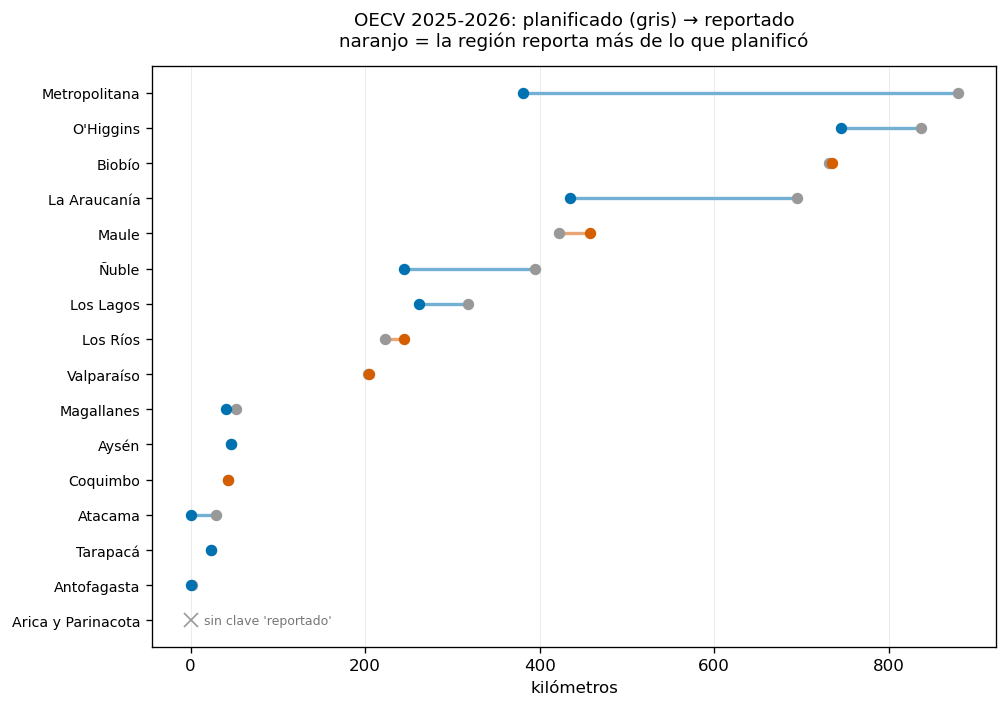

In [27]:
# Mancuerna planificado -> reportado. Se dibuja lo que hay: la region sin dato
# queda como hueco declarado, no como cero.
d = av.iloc[::-1]
y = np.arange(len(d))
fig, ax = plt.subplots(figsize=(8.5, 6), dpi=120)
for i, (idx, r) in enumerate(d.iterrows()):
    if pd.isna(r.reportado):
        ax.plot(r.Planificado, i, "x", color="#999", ms=8)
        ax.annotate("sin clave 'reportado'", (r.Planificado, i), xytext=(8, 0),
                    textcoords="offset points", va="center", fontsize=7.5, color="#777")
        continue
    color = "#D55E00" if r.reportado_supera_plan else "#0072B2"
    ax.plot([r.Planificado, r.reportado], [i, i], color=color, lw=2, alpha=0.55, zorder=1)
    ax.scatter(r.Planificado, i, s=34, color="#999", zorder=2)
    ax.scatter(r.reportado, i, s=34, color=color, zorder=3)
ax.set_yticks(y); ax.set_yticklabels(d.index, fontsize=8.5)
ax.set_xlabel("kilómetros"); ax.grid(axis="x", alpha=0.25, lw=0.6)
ax.set_title("OECV 2025-2026: planificado (gris) → reportado\n"
             "naranjo = la región reporta más de lo que planificó", pad=12, fontsize=11)
plt.tight_layout(); plt.show()

In [28]:
# oecv_verificado contra kpis.reportado. NO cuadra, y NO debe cuadrar: el propio
# visor declara que la capa verificada "no es el avance oficial" (config.js:288).
ver = cargar_lineas("oecv_verificado", man=man, geometria=False)
km_ver = ver.groupby("region", observed=True).longitud_km.sum()

comp = pd.DataFrame({"geometria verificada (km)": km_ver,
                     "kpis.reportado (km)": k.reportado.reindex(km_ver.index)})
comp["dif %"] = 100 * (comp.iloc[:, 0] - comp.iloc[:, 1]) / comp.iloc[:, 1]
print(f"la capa verificada suma {es(ver.longitud_km.sum(), 3)} km en {es(len(ver))} lineas,")
print(f"frente a {es(k.attrs['km_reportados'], 3)} km reportados a nivel nacional.\n")
print("Tarapaca reporta 23,0 km y no aporta NINGUNA geometria:",
      "Tarapacá" not in km_ver.index)
comp.sort_values("dif %", ascending=False)

la capa verificada suma 1.471,814 km en 1.114 lineas,
frente a 3.860,288 km reportados a nivel nacional.

Tarapaca reporta 23,0 km y no aporta NINGUNA geometria: True


,geometria verificada (km),kpis.reportado (km),dif %
region,,,
Valparaíso,753.71,203.90,269.65
Maule,538.81,457.28,17.83
Aysén,45.98,46.00,-0.05
Coquimbo,18.99,42.99,-55.83
Metropolitana,90.63,380.78,-76.20
Los Ríos,23.70,244.53,-90.31


## 7 · Mapas

Los colores salen de `frontend/src/config.js`, **no elegidos aquí**: la paleta de
causa es Okabe-Ito (distinguible con daltonismo, que importa cuando el color es la
única codificación) y la de OECV es **simbología oficial del Memo N° 3045/2025** de
la Gerencia de Protección contra Incendios Forestales de CONAF. Se lee del archivo
para que no pueda desincronizarse del visor, y **falla ruidosamente** si alguna
clase presente en los datos no tiene color.

> **Cómo leer estos mapas.** Se pinta una clase encima de otra, así que donde dos
> clases se solapan **gana la última dibujada**. Se dibuja de más a menos frecuente
> para que las clases raras queden encima —si no, `Naturales` (96 incendios) queda
> enterrada bajo `Negligentes` (8.730) y el mapa insinúa que no existe—. Aun así
> sirve para ver **dónde está cada clase**, no para leer proporciones en zonas
> mezcladas: para eso están las tablas de arriba y los paneles separados de abajo.
>
> Además hay **116 ubicaciones con más de un incendio** (238 puntos implicados, 122
> que quedan tapados). No se aplica *jitter*: mover un punto de su ubicación real
> sería falsear el dato.
>
> **No hay línea de costa ni cartografía de fondo**: este repositorio no trae
> ninguna capa de límites administrativos, y las dos capas viales son teselas
> vectoriales. En el mapa nacional la silueta la dibujan los propios incendios, y
> **no se superpone ninguna capa de contexto**: las fajas OECV caen en el mismo
> corredor que los puntos, así que quedan tapadas, y cualquier gris neutro que se
> les ponga choca con `Indeterminadas`, que también es gris. Las OECV sí aparecen,
> en su verde oficial, en el recorte regional del final.

In [29]:
PAL = lc.paleta_del_visor("causa", RAIZ, clases=list(df.causa_grupo.cat.categories))
ORDEN = lc.orden_dibujo(man, "causa_grupo")

print("paleta leida de frontend/src/config.js:")
for c, hexa in PAL.items():
    print(f"  {c:16} {hexa}   {es(int((df.causa_grupo == c).sum())):>6} incendios")
print()
print("orden de dibujo (de fondo a frente):", " · ".join(ORDEN))
print("  -> la clase mas frecuente al fondo, la mas rara encima")
print()
res, rep = lc.duplicados_coordenada(df)
print(f"coordenadas duplicadas: {res.ubicaciones[0]} ubicaciones, "
      f"{res.features[0]} incendios, {res.ocultos[0]} puntos tapados al dibujar")
print()
lat = df.lat
print(f"distorsion del aspecto: cos(lat) va de {np.cos(np.radians(lat.max())):.3f} "
      f"(norte, {lat.max():.1f}) a {np.cos(np.radians(lat.min())):.3f} (sur, {lat.min():.1f}).")
print("Un factor unico deforma un extremo; por eso la densidad de mas abajo va proyectada.")

paleta leida de frontend/src/config.js:
  Intencionales    #D55E00    4.484 incendios
  Negligentes      #E69F00    8.730 incendios
  Accidentales     #0072B2      972 incendios
  Naturales        #009E73       96 incendios
  Indeterminadas   #999999      423 incendios

orden de dibujo (de fondo a frente): Negligentes · Intencionales · Accidentales · Indeterminadas · Naturales
  -> la clase mas frecuente al fondo, la mas rara encima

coordenadas duplicadas: 116 ubicaciones, 238 incendios, 122 puntos tapados al dibujar

distorsion del aspecto: cos(lat) va de 0.951 (norte, -17.9) a 0.570 (sur, -55.2).
Un factor unico deforma un extremo; por eso la densidad de mas abajo va proyectada.


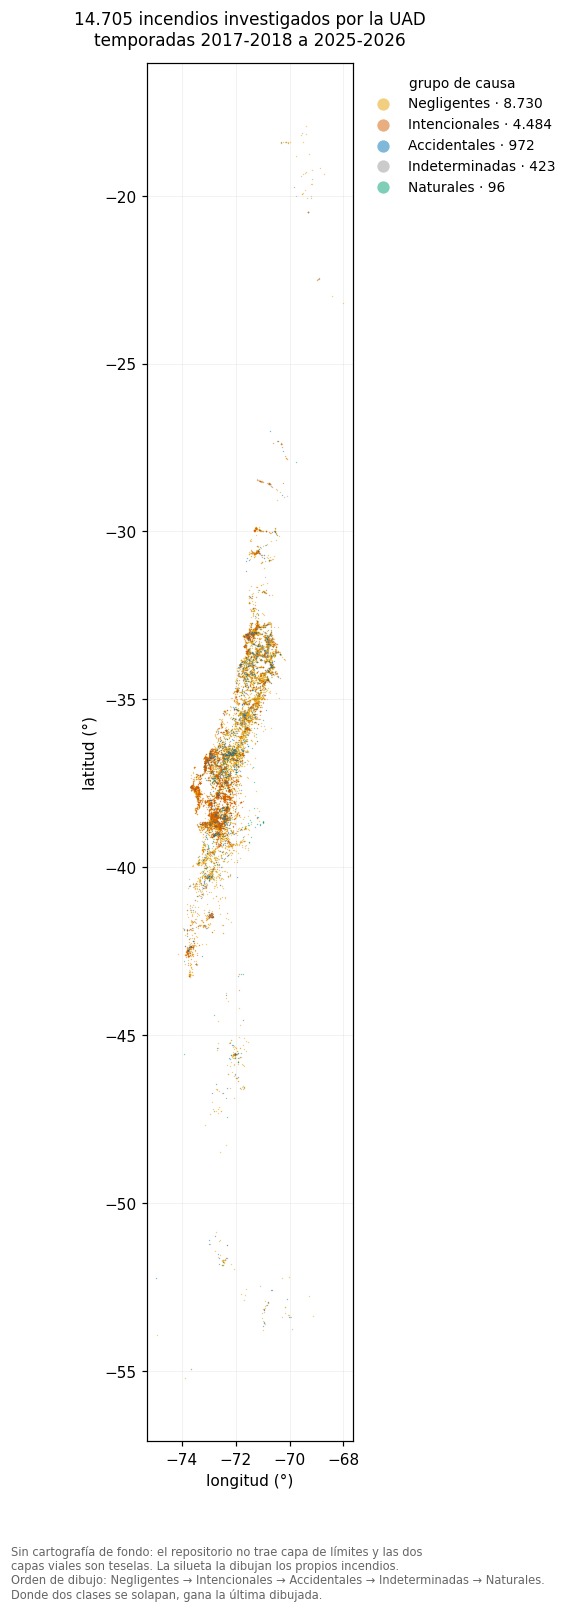

In [30]:
oecv = cargar_lineas("oecv", man=man)

fig, ax = plt.subplots(figsize=(6.2, 15), dpi=110)

# SIN capa de contexto a escala nacional, y por dos razones medidas: las fajas
# OECV son 4.790 km repartidos en el MISMO corredor donde caen los 14.705
# puntos, asi que quedan tapadas; y cualquier gris neutro que se les ponga
# choca con 'Indeterminadas' (#999999), que tambien es gris, de modo que el
# lector no podria distinguir una faja de un incendio de causa indeterminada.
# Las OECV se ven, en su verde oficial, en el recorte regional de mas abajo.

for cls in ORDEN:                       # de fondo a frente: la rara queda encima
    sel = df.causa_grupo == cls
    ax.scatter(df.lon[sel], df.lat[sel], s=3.2, marker=".", linewidths=0,
               alpha=0.5, rasterized=True, c=PAL[cls],
               label=f"{cls} · {es(int(sel.sum()))}", zorder=2 + ORDEN.index(cls))

ax.set_aspect(lc.aspecto_por_latitud(df.lat))
ax.set_xlabel("longitud (°)"); ax.set_ylabel("latitud (°)")
ax.set_title(f"{es(len(df))} incendios investigados por la UAD\n"
             f"temporadas {min(sorted(df.temporada.dropna().unique()))} a "
             f"{max(sorted(df.temporada.dropna().unique()))}", pad=12, fontsize=11)
ax.grid(alpha=0.2, lw=0.5)
leg = ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False,
                markerscale=9, fontsize=9, title="grupo de causa")
leg.get_title().set_fontsize(9)

# NADA de tight_layout aqui. Con un aspecto fijo, un pais de 38 grados de latitud
# y la leyenda fuera del eje, matplotlib avisa "the left and right margins cannot
# be made large enough" y el backend inline acaba colapsando la figura a una
# franja de 1194x211 px. Se ajustan los margenes a mano y el pie va en
# coordenadas de FIGURA, no del eje.
fig.subplots_adjust(left=0.14, right=0.60, top=0.94, bottom=0.105)
fig.text(0.02, 0.008,
         "Sin cartografía de fondo: el repositorio no trae capa de límites y las dos\n"
         "capas viales son teselas. La silueta la dibujan los propios incendios.\n"
         "Orden de dibujo: " + " → ".join(ORDEN) + ".\n"
         "Donde dos clases se solapan, gana la última dibujada.",
         fontsize=7.5, color="#666", va="bottom", ha="left")
plt.show()

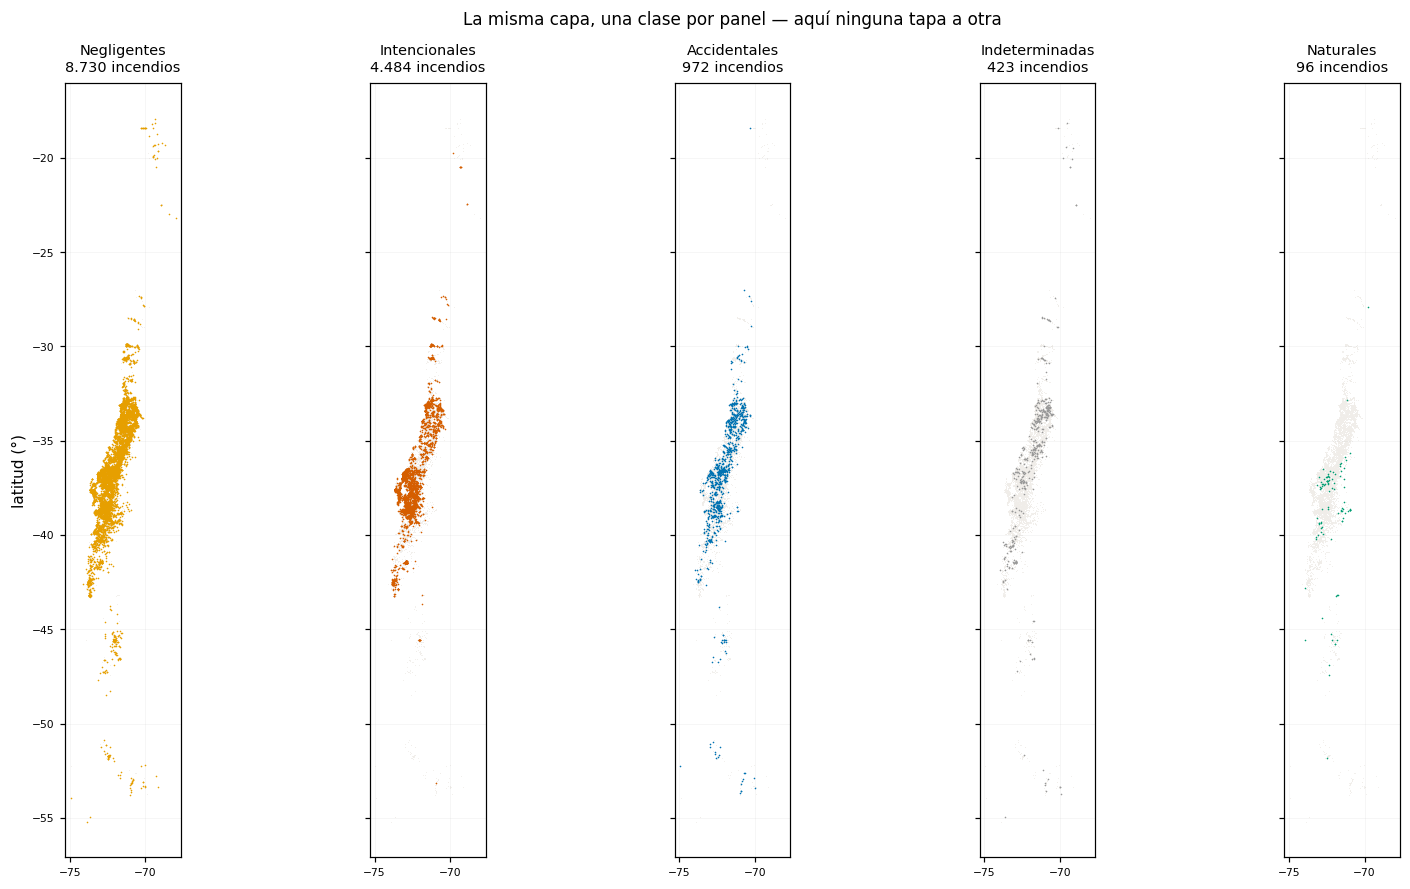

In [31]:
# Un panel por clase, con el resto en gris al fondo. Es la unica forma de que
# ninguna clase tape a otra: en el mapa de arriba, Naturales y Indeterminadas
# desaparecen bajo las dos mayoritarias.
clases = list(df.causa_grupo.cat.categories)
fig, axes = plt.subplots(1, len(clases), figsize=(15, 8.2), dpi=110, sharex=True, sharey=True)
for ax, cls in zip(axes, clases):
    sel = df.causa_grupo == cls
    ax.scatter(df.lon, df.lat, s=1.2, marker=".", linewidths=0, c="#f0ede9",
               rasterized=True, zorder=1)
    ax.scatter(df.lon[sel], df.lat[sel], s=4.5, marker=".", linewidths=0,
               c=PAL[cls], rasterized=True, zorder=2)
    ax.set_aspect(lc.aspecto_por_latitud(df.lat))
    ax.set_title(f"{cls}\n{es(int(sel.sum()))} incendios", fontsize=9.5, pad=8)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.18, lw=0.4)
axes[0].set_ylabel("latitud (°)")
fig.suptitle("La misma capa, una clase por panel — aquí ninguna tapa a otra", y=0.98, fontsize=11)
plt.tight_layout(); plt.show()

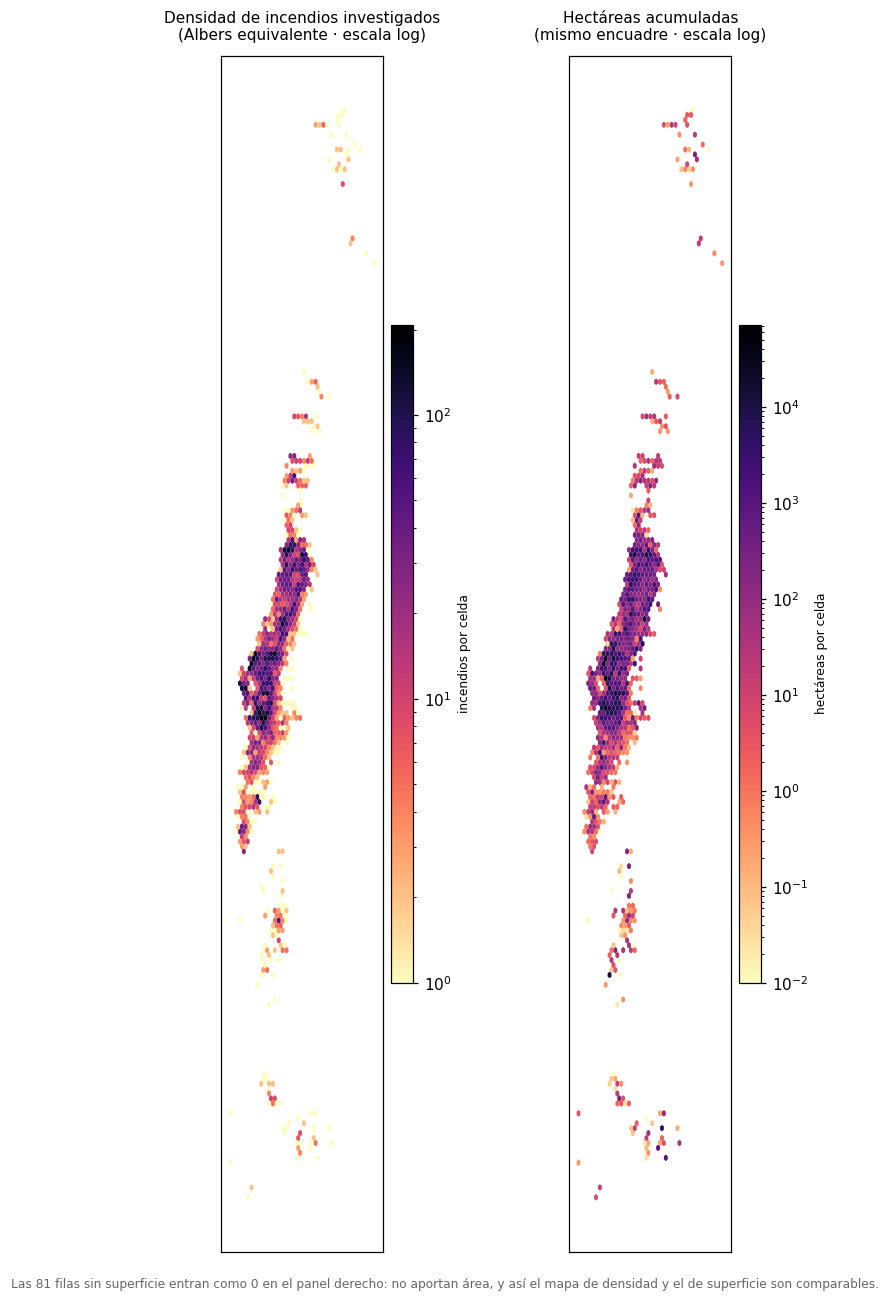

In [32]:
# Densidad. Aqui el area SI importa, asi que se proyecta a metros con una
# proyeccion EQUIVALENTE (Albers): una rejilla hexagonal sobre lon/lat tendria
# celdas de area distinta segun la latitud, y en un pais de 38 grados eso no es
# un detalle. Colormap secuencial, no la paleta categorica.
x, y = lc.proyectar(df.lon, df.lat)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(7.5, 12), dpi=110)
hb = a1.hexbin(x, y, gridsize=(38, 110), bins="log", cmap="magma_r", mincnt=1, linewidths=0)
a1.set_aspect("equal")
a1.set_title("Densidad de incendios investigados\n(Albers equivalente · escala log)", fontsize=10, pad=10)
a1.set_xticks([]); a1.set_yticks([])
cb = fig.colorbar(hb, ax=a1, shrink=0.55, pad=0.02, aspect=30); cb.set_label("incendios por celda", fontsize=8)

sup = df.superficie_ha.fillna(0).to_numpy()
hb2 = a2.hexbin(x, y, C=sup, reduce_C_function=np.sum, gridsize=(38, 110),
                cmap="magma_r", mincnt=1, linewidths=0, norm=plt.matplotlib.colors.LogNorm())
a2.set_aspect("equal")
a2.set_title("Hectáreas acumuladas\n(mismo encuadre · escala log)", fontsize=10, pad=10)
a2.set_xticks([]); a2.set_yticks([])
cb2 = fig.colorbar(hb2, ax=a2, shrink=0.55, pad=0.02, aspect=30); cb2.set_label("hectáreas por celda", fontsize=8)
fig.text(0.5, 0.02, "Las 81 filas sin superficie entran como 0 en el panel derecho: "
         "no aportan área, y así el mapa de densidad y el de superficie son comparables.",
         ha="center", fontsize=8, color="#666")
plt.tight_layout(rect=(0, 0.035, 1, 1)); plt.show()

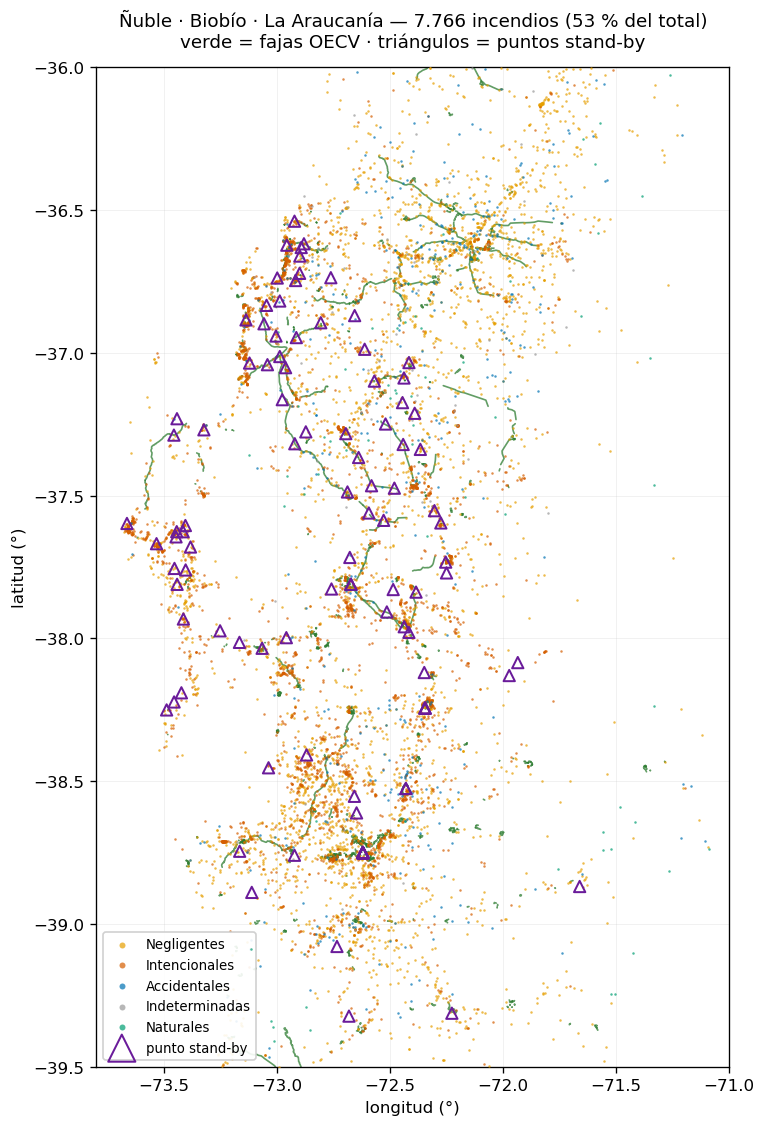

In [33]:
# Recorte donde se concentra el dato, con las OECV y los puntos stand-by encima.
standby = cargar_puntos(man=man)
LAT = (-39.5, -36.0)
sub = df[df.lat.between(*LAT)]
sb  = standby[standby.lat.astype(float).between(*LAT)]

fig, ax = plt.subplots(figsize=(8, 9.5), dpi=120)
for g in oecv.geometria:
    partes = [g["coordinates"]] if g["type"] == "LineString" else g["coordinates"]
    for p in partes:
        xs, ys = zip(*[(c[0], c[1]) for c in p])
        if min(ys) > LAT[1] or max(ys) < LAT[0]:
            continue
        ax.plot(xs, ys, color="#2E7D32", lw=1.0, alpha=0.75, zorder=2, solid_capstyle="round")
for cls in ORDEN:
    sel = sub.causa_grupo == cls
    ax.scatter(sub.lon[sel], sub.lat[sel], s=9, marker=".", linewidths=0,
               alpha=0.7, c=PAL[cls], label=cls, zorder=3 + ORDEN.index(cls))
ax.scatter(sb.lon.astype(float), sb.lat.astype(float), s=46, marker="^",
           facecolor="none", edgecolor="#6A1B9A", lw=1.2, zorder=9, label="punto stand-by")

ax.set_xlim(-73.8, -71.0); ax.set_ylim(*LAT)
ax.set_aspect(lc.aspecto_por_latitud(sub.lat))
ax.set_xlabel("longitud (°)"); ax.set_ylabel("latitud (°)")
ax.set_title(f"Ñuble · Biobío · La Araucanía — {es(len(sub))} incendios "
             f"({100 * len(sub) / len(df):.0f} % del total)\n"
             "verde = fajas OECV · triángulos = puntos stand-by", pad=12, fontsize=11)
ax.legend(loc="lower left", frameon=True, framealpha=0.9, fontsize=8, markerscale=2.4)
ax.grid(alpha=0.2, lw=0.5)
plt.tight_layout(); plt.show()

## 8 · Exportar

Parquet conserva los tipos y las categóricas y lo abren DuckDB, polars, R y QGIS sin
adaptador. **Junto al dato se escriben las tablas del manifest**: sin ellas, un
archivo con columnas `<campo>_cod` es indescifrable en otra corrida del ETL, porque
el índice es *posicional* y se reordena por frecuencia. Desde la terminal:

```
python analisis/leer_capas.py --parquet analisis/salidas/incendios.parquet
```

In [34]:
import json

SALIDAS = RAIZ / "analisis" / "salidas"
SALIDAS.mkdir(parents=True, exist_ok=True)

df.to_parquet(SALIDAS / "incendios.parquet", index=False, compression="zstd")
# utf-8-sig: sin BOM, Excel en Windows abre las tildes rotas. Y separador ';' con
# coma decimal, que es lo que espera Excel en espanol de Chile.
df.to_csv(SALIDAS / "incendios.csv", index=False, sep=";", decimal=",", encoding="utf-8-sig")
(SALIDAS / "procedencia.json").write_bytes(json.dumps({
    "fuente": "CONAF · Unidad de Información y Análisis",
    "esquema": lc.ESQUEMA, "generado_etl": man["generado"], "huella": man["_huella"],
    "aviso": lc.ADVERTENCIA_PRINCIPAL,
    "sobre_los_cod": "las columnas <campo>_cod son POSICIONES en estas tablas, "
                     "no códigos oficiales; se reordenan por frecuencia en cada "
                     "corrida del ETL. Los códigos oficiales son causa_codigo y "
                     "causa_general_codigo.",
    "tablas": man["capas"]["incendios"]["tablas"],
}, ensure_ascii=False, indent=2).encode("utf-8"))

for p in sorted(SALIDAS.iterdir()):
    print(f"  {p.name:24} {es(p.stat().st_size / 1e6, 2):>8} MB")

  incendios.csv                5,39 MB
  incendios.parquet            1,08 MB
  incendios_tablas.json        0,02 MB
  procedencia.json             0,02 MB


---

### Lo que este dataset **no** puede responder

Esto vale más que cualquier tabla de arriba, porque es lo que evita una conclusión
falsa.

**Universo y ocurrencia**

- **Cuántos incendios hubo en Chile.** Son los **investigados por la UAD**: 14.705
  publicados de 14.985 filas de origen. No es una muestra aleatoria.
- **Si los incendios aumentan o disminuyen.** La serie mezcla ocurrencia con
  ampliación de la cobertura de investigación. Sólo las proporciones son
  razonablemente robustas, y por eso §6 dibuja las dos.
- **Tasas o riesgo por comuna o región.** No hay denominador: ni superficie
  vegetal, ni población, ni exposición, ni interfaz urbano-rural.
- **Qué pasó con las 280 filas descartadas.** No están listadas: auditar el sesgo
  del descarte obliga a volver al Excel de origen.

**Geometría y superficie**

- **No trae perímetros.** Cada incendio es un **punto**. `superficie_ha` se puede
  sumar, pero no mapear como área ni intersecar con cuencas, predios o buffers.
- **La precisión posicional no está declarada.** 5 decimales es precisión de
  almacenamiento, no exactitud: el huso UTM de origen no venía declarado y se
  dedujo por región. **No sirve para nada predial ni legal.**
- **Distinguir «incendio diminuto» de «superficie no registrada»** entre las 71
  filas con `0,0`: el redondeo a 2 decimales del ETL colapsa todo lo menor a
  0,005 ha.

**Tiempo**

- **No hay fecha de ocurrencia del fuego.** `inicio_r20` es del reporte R20;
  `inv_inicio` e `inv_fin` son de la **investigación**, y faltan en el 33,25 % y
  22,73 % de las filas. Sin curvas horarias, estacionalidad ni duración fiables —y
  24 filas tienen la investigación terminando antes de empezar.

**Causa y responsabilidad**

- **Es la causa principal, no una composición.** Los tres niveles son un único
  árbol por incendio, no un reparto entre causas concurrentes.
- **Ni la etiqueta ni el código de `causa_general` identifican solos:** 9 etiquetas
  tienen más de un código oficial, y los códigos `4.1` y `1.1` llevan dos etiquetas
  distintas cada uno. Hay que decir cuál se usa.
- **Nada sobre jefes de brigada.** Pese al encabezado, esa columna no trae personas.
- **Nada judicial.** La causa es una determinación técnica de la UAD, no una
  imputación: es un recuento de lo ocurrido, no una lista de recomendaciones ni una
  norma.

**Territorio**

- **Sin códigos INE/DPA.** Sólo nombres, y con 35 comunas escritas de varias formas.
  Cualquier cruce con población o cartografía oficial exige una tabla de
  correspondencia externa que aquí no existe.

**OECV y prevención**

- **Si las OECV redujeron incendios.** No: sin pre/post ni contrafactual. Las obras
  se emplazan por exposición, no en proporción a la superficie quemada, y son una
  **foto de la temporada 2025-2026** contra **nueve temporadas** de incendios.
- **Cuántos kilómetros se construyeron.** Hay tres cifras incompatibles —4.898,595
  planificados, 3.860,288 reportados y 4.789,779 de geometría dibujada— y **cinco
  regiones reportan más de lo que planificaron**.
- **`oecv_verificado` no es el avance oficial**, y el propio visor lo declara. No
  reconcilia con `kpis.reportado` en ninguna región salvo Aysén, y Tarapacá reporta
  23 km sin aportar geometría alguna.
- **Re-derivar `longitud_km` desde la geometría publicada:** está simplificada a
  10 m; el ETL midió geodésicamente **antes** de simplificar.

**Cobertura operativa**

- **Dónde hay o no hay brigadas.** 327 puntos stand-by en **7 de 16 regiones**: la
  ausencia es de registro en la fuente, no necesariamente de brigadas.
- **Red vial y accesibilidad.** `rutas` y `redvial` son PMTiles con simplificación y
  descarte por densidad: sus 5.278 y 13.964 features son cifras del manifest, **no
  filas recuperables**. Para tenerlas como features hay que regenerarlas con
  `python ETL/run.py --layers redvial --no-tiles --out <carpeta_aparte>`.

**Y una de fondo**

- **Este visor no muestra incendios activos.** No sirve para operación en
  emergencia, ni para saber qué está ardiendo ahora, ni para decidir una evacuación.